***Student Marks Prediction Model using Kaggle Dataset***

In [53]:
# Step 1 : Import Libraries
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [54]:
# Step 2 : Download Dataset from Kaggle
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
print(" Dataset downloaded at:", path)

# Step 3 : Load Dataset
# The dataset contains 'StudentsPerformance.csv'
df = pd.read_csv(path + "/StudentsPerformance.csv")

print("\n------------------------------------------------------------------------------------------------")

# ================================
#  Basic EDA
# ================================
print("\n📊 Dataset Info:")
print(df.info())

print("\n------------------------------------------------------------------------------------------------")

print("\n📊 Statistical Summary:")
print(df.describe())

print("\n------------------------------------------------------------------------------------------------")

# Check missing values
print("\n❗ Missing Values:")
print(df.isnull().sum())

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
 Dataset downloaded at: /kaggle/input/students-performance-in-exams

------------------------------------------------------------------------------------------------

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

-

In [55]:
# Step 4 : Display Data
print("\n Sample Data:\n")
print(df.head())
print("\nShape of dataset:", df.shape)

print("\n------------------------------------------------------------------------------------------------")

# Step 5 : Data Preprocessing
# Convert categorical variables to numeric (since model needs numeric inputs)
df.rename(columns=lambda x: x.strip().replace(" ", "_"), inplace=True)

# Encode categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

print("\n After Encoding:\n")
print(df.head())

# Step 6 : Define Features & Target
X = df.drop(['math_score'], axis=1)
y = df['math_score']

# Step 7 : Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 : Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 9 : Evaluate Model
y_pred = model.predict(X_test)


# 🌲 Step 10 : Random Forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)




 Sample Data:

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Shape of dataset: (1000, 8)

------------------------------------------------------------------------------------------------

 After Encoding

In [56]:
print("\n------------------------------------------------------------------------------------------------")

# Evaluate random forest model
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📊 {model_name} Performance:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R² Score:", r2_score(y_true, y_pred))


evaluate_model(y_test, rf_pred, "Random Forest")

print("\n------------------------------------------------------------------------------------------------")

# Evaluate linear regression model
evaluate_model(y_test, y_pred, "Linear Regression")

print("\n------------------------------------------------------------------------------------------------")



------------------------------------------------------------------------------------------------

📊 Random Forest Performance:
MAE: 4.70082380952381
MSE: 36.79422162429139
R² Score: 0.8487940184356789

------------------------------------------------------------------------------------------------

📊 Linear Regression Performance:
MAE: 4.1301450780040545
MSE: 28.275284506327335
R² Score: 0.8838026201112223

------------------------------------------------------------------------------------------------


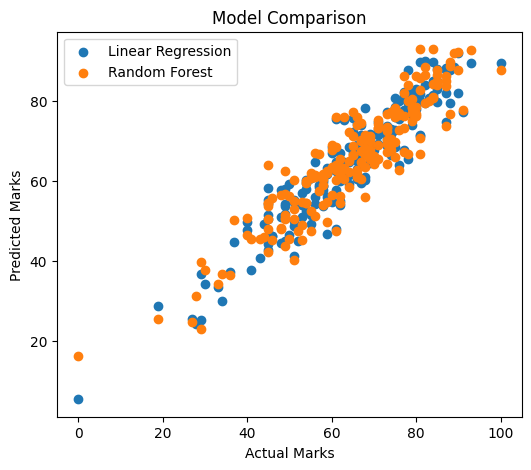

In [57]:
# 📊 Step 11 : Visualization Comparison

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, label="Linear Regression")
plt.scatter(y_test, rf_pred, label="Random Forest")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Model Comparison")
plt.legend()
plt.show()

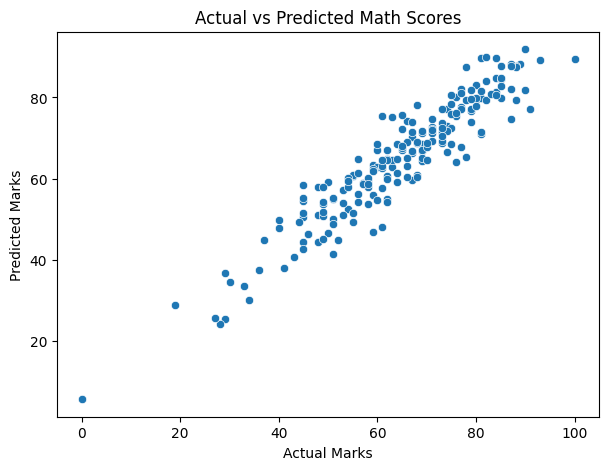

In [58]:
# Step 12 : Visualization
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Math Scores")
plt.show()

In [59]:
# Step 13 : Predict Example
print("\n # Example Prediction:\n")
sample_data = X_test.iloc[0:1]
print("Input features:\n", sample_data)
pred = model.predict(sample_data)
print("\n  \n")
print(f"Predicted Math Score: {pred[0]:.2f}")


 # Example Prediction:

Input features:
      gender  race/ethnicity  parental_level_of_education  lunch  \
521       0               2                            0      1   

     test_preparation_course  reading_score  writing_score  
521                        1             86             84  

  

Predicted Math Score: 77.12


In [60]:
# 🏁 Step 14 : Final Summary

lr_r2 = r2_score(y_test, y_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\n================ FINAL SUMMARY ================")

print(f"Linear Regression R² Score: {lr_r2:.4f}")
print(f"Random Forest R² Score: {rf_r2:.4f}")

if rf_r2 > lr_r2:
    print("\n✅ Random Forest performs better!")
else:
    print("\n✅ Linear Regression performs better!")

print("\n📌 Conclusion:")
print("- Linear Regression is simple and interpretable.")
print("- Random Forest captures complex patterns and usually gives better accuracy.")
print("- For this dataset, the better model is chosen based on R² score.")


================ FINAL SUMMARY ================
Linear Regression R² Score: 0.8838
Random Forest R² Score: 0.8488

✅ Linear Regression performs better!

📌 Conclusion:
- Linear Regression is simple and interpretable.
- Random Forest captures complex patterns and usually gives better accuracy.
- For this dataset, the better model is chosen based on R² score.
